# CSV
Para descargar el dataset: https://maven-datasets.s3.us-east-1.amazonaws.com/Spotify+Streaming+History/Spotify+Streaming+History.zip


In [8]:
# Montamos el drive en nuestra notebook para poder trabajar
#con documentos que tenemos guardados ahí
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
# Deben ponder la ruta en que uds tienen el dataset en su Google Drive
path = 'gdrive/My Drive/Colab Notebooks/datasets/spotify_history.csv'

Mounted at /content/gdrive


##Importar CSV con Pandas

In [9]:
import pandas as pd

El día de la semana en el que se escuchó más música fue el **Viernes**.

In [20]:
# Día de la semana más activo
dia_mas_activo = spotify_data.groupby("dia_semana")["minutos_reproducidos"].sum().sort_values(ascending=False).head(1)
display(dia_mas_activo)

,minutos_reproducidos
dia_semana,
Friday,52998.1


In [11]:
# Leemos el CSV
# path = "/content/spotify_history.csv" # This was causing the error

spotify_data = pd.read_csv(path)

# Leemos los 5 primeros datos
spotify_data.head()

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2J3n32GeLmMjwuAzyhcSNe,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,1oHxIPqJyvAYHy0PVrDU98,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,487OPlneJNni3NWC8SYqhW,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False
3,5IyblF777jLZj1vGHG2UD3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False
4,0GgAAB0ZMllFhbNc3mAodO,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False


In [12]:
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   spotify_track_uri  149860 non-null  object
 1   ts                 149860 non-null  object
 2   platform           149860 non-null  object
 3   ms_played          149860 non-null  int64 
 4   track_name         149860 non-null  object
 5   artist_name        149860 non-null  object
 6   album_name         149860 non-null  object
 7   reason_start       149717 non-null  object
 8   reason_end         149743 non-null  object
 9   shuffle            149860 non-null  bool  
 10  skipped            149860 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 10.6+ MB


In [13]:
spotify_data.describe()

,ms_played
count,1.498600e+05
mean,1.283166e+05
std,1.178401e+05
min,0.000000e+00
25%,2.795000e+03
50%,1.388400e+05
75%,2.185070e+05
max,1.561125e+06


In [14]:
# Cuando el CSV tiene sus nombres de columna definidos, puedo directamente armar mi DataFrame con las columnas que me interesan.
# Por ej. puedo leer todo menos la columna de spotify_track_uri porque no me aporta información relevante
usecols = ["ts","platform","ms_played","track_name","artist_name","album_name","reason_start","reason_end","shuffle","skipped"]

spotify_data = pd.read_csv(path, usecols=usecols)

spotify_data.head()

,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False
3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False
4,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False


## Limpieza de datos

In [15]:
# Convertimos los datos para poder trabajarlos
import datetime as dt

# Convertimos el tipo de dato de ts a fecha y hora
spotify_data['ts'] = pd.to_datetime(spotify_data['ts'])

# Pasamos ms_played de milisegundos a minutos
spotify_data['minutos_reproducidos'] = spotify_data['ms_played'] / 60000

# Agregamos columnas que pueden servirnos para el análisis
spotify_data['fecha'] = spotify_data['ts'].dt.date
spotify_data['hora'] = spotify_data['ts'].dt.hour
spotify_data['dia_semana'] = spotify_data['ts'].dt.day_name()

spotify_data['mes'] = spotify_data['ts'].dt.month
spotify_data['anio'] = spotify_data['ts'].dt.year

spotify_data.head()

,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped,minutos_reproducidos,fecha,hora,dia_semana,mes,anio
0,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False,0.053083,2013-07-08,2,Monday,7,2013
1,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False,1.031083,2013-07-08,2,Monday,7,2013
2,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False,4.756433,2013-07-08,2,Monday,7,2013
3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False,2.233700,2013-07-08,2,Monday,7,2013
4,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False,0.000000,2013-07-08,3,Monday,7,2013


In [ ]:
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   spotify_track_uri     149860 non-null  object        
 1   ts                    149860 non-null  datetime64[ns]
 2   platform              149860 non-null  object        
 3   ms_played             149860 non-null  int64         
 4   track_name            149860 non-null  object        
 5   artist_name           149860 non-null  object        
 6   album_name            149860 non-null  object        
 7   reason_start          149717 non-null  object        
 8   reason_end            149743 non-null  object        
 9   shuffle               149860 non-null  bool          
 10  skipped               149860 non-null  bool          
 11  minutos_reproducidos  149860 non-null  float64       
 12  fecha                 149860 non-null  object        
 13 

In [ ]:
# Quitar columnas
# Elimina UNA columna
spotify_data = spotify_data.drop(columns=["spotify_track_uri"])

# Elimina VARIAS columnas
#spotify_data = spotify_data.drop(columns=["ms_played", "ts"])

spotify_data.head()

,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped,minutos_reproducidos,fecha,hora,dia_semana,mes,anio
0,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False,0.053083,2013-07-08,2,Monday,7,2013
1,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False,1.031083,2013-07-08,2,Monday,7,2013
2,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False,4.756433,2013-07-08,2,Monday,7,2013
3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False,2.233700,2013-07-08,2,Monday,7,2013
4,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False,0.000000,2013-07-08,3,Monday,7,2013


In [ ]:
# Buscar los datos nulos

spotify_data[spotify_data.isnull().any(axis=1)]
# axis=1 revisa columnas (filas completas)
# Devuelve solo las filas donde alguna columna es nula

,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped,minutos_reproducidos,fecha,hora,dia_semana,mes,anio
577,2015-08-12 02:26:11,iOS,283466,From Eden,Hozier,Hozier,NaN,trackdone,False,False,4.724433,2015-08-12,2,Wednesday,8,2015
596,2015-08-12 05:03:15,iOS,40681,Shades Of Cool,Lana Del Rey,Ultraviolence,trackdone,NaN,False,True,0.678017,2015-08-12,5,Wednesday,8,2015
597,2015-08-12 05:07:44,iOS,268173,Staying Up,The Neighbourhood,I Love You.,NaN,trackdone,False,False,4.469550,2015-08-12,5,Wednesday,8,2015
605,2015-08-12 05:23:23,iOS,41145,El Karma,Noel Torres,La Balanza,trackdone,NaN,False,True,0.685750,2015-08-12,5,Wednesday,8,2015
606,2015-08-12 05:24:10,iOS,46997,Tentándome,Juan Magán,The King Is Back,NaN,endplay,False,True,0.783283,2015-08-12,5,Wednesday,8,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10088,2017-01-06 19:14:00,iOS,253866,Custard Pie - 1990 Remaster,Led Zeppelin,Physical Graffiti,NaN,trackdone,False,False,4.231100,2017-01-06,19,Friday,1,2017
11368,2017-01-14 02:45:35,iOS,168344,Sweet Emotion,Aerosmith,Toys In The Attic,trackdone,NaN,True,True,2.805733,2017-01-14,2,Saturday,1,2017
11369,2017-01-14 02:45:58,iOS,0,Riot Van,Arctic Monkeys,"Whatever People Say I Am, That's What I'm Not",NaN,fwdbtn,False,True,0.000000,2017-01-14,2,Saturday,1,2017
24557,2017-08-21 16:53:00,iOS,85495,All I Can Think About Is You,Coldplay,All I Can Think About Is You,NaN,NaN,False,True,1.424917,2017-08-21,16,Monday,8,2017


In [ ]:
# Para sacar las filas que tienen datos nulos puedo hacer la consulta inversa y reemplazar el dataFrame
spotify_data = spotify_data[spotify_data.notnull().all(axis=1)]
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149648 entries, 0 to 149859
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ts                    149648 non-null  datetime64[ns]
 1   platform              149648 non-null  object        
 2   ms_played             149648 non-null  int64         
 3   track_name            149648 non-null  object        
 4   artist_name           149648 non-null  object        
 5   album_name            149648 non-null  object        
 6   reason_start          149648 non-null  object        
 7   reason_end            149648 non-null  object        
 8   shuffle               149648 non-null  bool          
 9   skipped               149648 non-null  bool          
 10  minutos_reproducidos  149648 non-null  float64       
 11  fecha                 149648 non-null  object        
 12  hora                  149648 non-null  int32         
 13  dia_

## Análisis Exploratorio

El análisis exploratorio nos ayuda a conocer un poco más los datos que tenemos. Empezamos a contestarnos ciertas preguntas.

Para esto, podemos utilizar algunas funciones de pandas como el conteo o las agrupaciones.

**value_counts**

El ***value_counts()*** en pandas es muy práctica para hacer conteos rápidos de valores únicos en una columna del dataFrame (Series)

```
Series.value_counts(
    normalize=False,
    sort=True,
    ascending=False,
    bins=None,
    dropna=True
)
```



In [ ]:
spotify_data['skipped'].value_counts()

,count
skipped,
False,141902
True,7746


**Parámetros principales**

* `normalize (bool, False por defecto)`

  Si True, devuelve proporciones (%) en lugar de conteos.

* `sort (bool, True por defecto)`

  Si *True*, ordena de mayor a menor frecuencia.

  Si *False*, respeta el orden original.

* `ascending (bool, False por defecto)`

  Orden ascendente (True) o descendente (False).

* `bins (int, opcional)`

  Divide valores numéricos entreros en intervalos.

* `dropna (bool, True por defecto)`

  Si False, incluye también los valores nulos (NaN) en el conteo.

In [ ]:
spotify_data['skipped'].value_counts(normalize=True)

,proportion
skipped,
False,0.948239
True,0.051761


In [ ]:
spotify_data['reason_start'].value_counts(sort=True)

,count
reason_start,
trackdone,76599
fwdbtn,53785
clickrow,11224
appload,3729
backbtn,2204
playbtn,1458
remote,477
trackerror,120
unknown,23


In [ ]:
spotify_data['hora'].value_counts(bins=5)

,count
"(18.4, 23.0]",46747
"(-0.024, 4.6]",44148
"(13.8, 18.4]",31332
"(4.6, 9.2]",22929
"(9.2, 13.8]",4492


In [ ]:
spotify_data['reason_start'].value_counts(dropna=False)
# En la lista aparecen los NaN (valores nulos)

De esta manera podemos hacer análisis como:

In [ ]:
# Canciones más reproducidas (sin skip)
print(spotify_data[spotify_data['skipped'] == False]['track_name'].value_counts().head(10))

track_name
Ode To The Mets                      206
In the Blood                         180
Dying Breed                          164
Caution                              162
For What It's Worth                  145
19 Dias y 500 Noches - En Directo    143
All These Things That I've Done      139
Come Together - Remastered 2009      135
Concerning Hobbits                   135
Yesterday - Remastered 2009          133
Name: count, dtype: int64


In [ ]:
# Misma consulta con más datos a mostrar
print(spotify_data[spotify_data['skipped'] == False][['track_name','artist_name','album_name']].value_counts().head(10))

track_name                         artist_name     album_name                                                                            
Ode To The Mets                    The Strokes     The New Abnormal                                                                          206
In the Blood                       John Mayer      The Search for Everything                                                                 180
19 Dias y 500 Noches - En Directo  Joaquín Sabina  Nos Sobran Los Motivos                                                                    143
All These Things That I've Done    The Killers     Hot Fuss                                                                                  139
Concerning Hobbits                 Howard Shore    The Lord of the Rings: The Fellowship of the Ring (Original Motion Picture Soundtrack)    135
Come Together - Remastered 2009    The Beatles     Abbey Road                                                                            

In [ ]:
# Reproducciones por plataforma
print(spotify_data['platform'].value_counts())

platform
android           139821
cast to device      3893
iOS                 2842
windows             1691
mac                 1176
web player           225
Name: count, dtype: int64


**groupby()**

La sentencia ***groupby()*** se usa para agrupar filas de un DataFrame en función de una o varias columnas, y luego aplicar una operación (suma, promedio, conteo, etc.) sobre cada grupo.

La estructura general es:

`df.groupby("columna").operación()`

Operaciones que se pueden aplicar:

* `sum()` suma valores.
* `mean()` promedio.
* `max()`, `min()` valor máximo y mínimo respectivamente.
* `count()` cuenta valores no nulos.
* `size()` cuenta todas las filas.

In [ ]:
# Agrupamos por nombre de artista y sumamos los minutos reproducidos
spotify_data.groupby('artist_name')['minutos_reproducidos'].sum()

,minutos_reproducidos
artist_name,
"""Weird Al"" Yankovic",1.113667
*NSYNC,7.594917
.Sinh,1.381567
070 Shake,7.165700
"10,000 Maniacs",3.136667
...,...
Örjan Hultén Orion,0.801983
ゼロ戦,24.881083
岸正之,9.124433


In [ ]:
# Si quiero ordenar los datos y solo mostrar los 10 primeros
spotify_data.groupby('artist_name')['minutos_reproducidos'].sum().sort_values(ascending=False).head(10)

,minutos_reproducidos
artist_name,
The Beatles,20166.720767
The Killers,17654.558383
John Mayer,12078.435600
Bob Dylan,9475.533233
Paul McCartney,5955.906167
Howard Shore,5815.511250
The Strokes,5284.948333
The Rolling Stones,5131.950150
Pink Floyd,4342.197367


In [ ]:
# count() cuenta solo valores no nulos.
spotify_data.groupby('fecha')['album_name'].count()

,album_name
fecha,
2013-07-08,65
2013-07-09,29
2013-07-10,6
2013-07-11,2
2013-07-12,1
...,...
2024-12-09,6
2024-12-10,56
2024-12-13,3


In [ ]:
# size() cuenta todas las filas, incluso si hay valores nulos.
spotify_data.groupby('fecha')['album_name'].size()

,album_name
fecha,
2013-07-08,65
2013-07-09,29
2013-07-10,6
2013-07-11,2
2013-07-12,1
...,...
2024-12-09,6
2024-12-10,56
2024-12-13,3


In [ ]:
# Artistas más reproducidos por minutos
print(spotify_data.groupby('artist_name')['minutos_reproducidos'].sum().sort_values(ascending=False).head(10))

artist_name
The Beatles           20166.720767
The Killers           17654.558383
John Mayer            12078.435600
Bob Dylan              9475.533233
Paul McCartney         5955.906167
Howard Shore           5815.511250
The Strokes            5284.948333
The Rolling Stones     5131.950150
Pink Floyd             4342.197367
Led Zeppelin           4123.667667
Name: minutos_reproducidos, dtype: float64


## Análisis Temporal

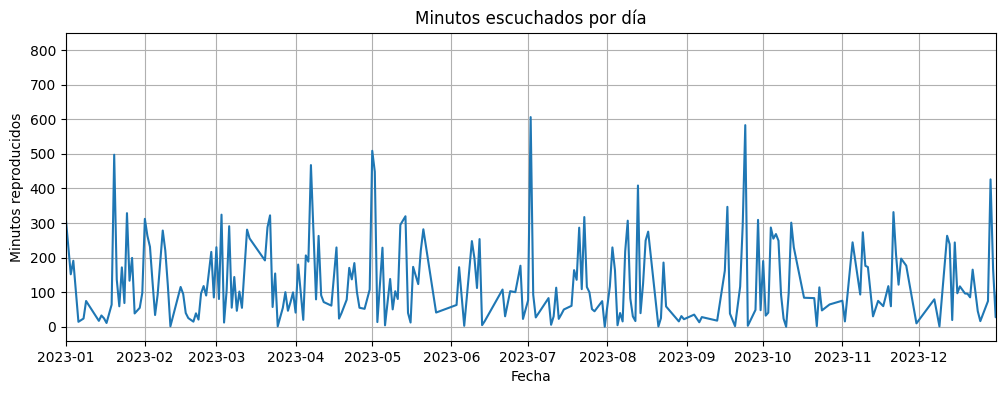

In [ ]:
import matplotlib.pyplot as plt

spotify_data.groupby("fecha")["minutos_reproducidos"].sum().plot(kind="line", figsize=(12, 4), title="Minutos escuchados por día")
plt.xlabel("Fecha")
plt.ylabel("Minutos reproducidos")
#plt.xlim('2023-01-01','2023-12-31')
plt.grid(True)
plt.show()


In [ ]:
# Día de la semana más activo
spotify_data.groupby("dia_semana")["minutos_reproducidos"].sum().sort_values(ascending=False)

,minutos_reproducidos
dia_semana,
Friday,52954.105033
Wednesday,48959.721133
Thursday,47510.728217
Tuesday,46448.229250
Monday,45898.474000
Sunday,39211.361883
Saturday,39002.076500


# ACTIVIDAD

Buscar y mostrar:

* ¿Cuál fue el día de la semana en el que se escuchó más música?
* ¿Qué artista tuvo más reproducciones en dispositivos Android?
* ¿Cuál es la canción más reproducida en modo aleatorio (`shuffle == True`)?
* ¿Cuál fue el álbum más reproducido durante todo el historial?

El álbum más reproducido durante todo el historial es **The New Abnormal**.

In [19]:
# Agrupar por nombre de álbum y sumar los minutos reproducidos
album_mas_reproducido = spotify_data.groupby('album_name')['minutos_reproducidos'].sum().sort_values(ascending=False).head(1)

# Mostrar el resultado
display(album_mas_reproducido)

,minutos_reproducidos
album_name,
The New Abnormal,3112.631583


La canción más reproducida en modo aleatorio es **In the Blood**.

In [18]:
# Filtrar datos por modo aleatorio
shuffle_data = spotify_data[spotify_data['shuffle'] == True]

# Contar la frecuencia de cada canción y encontrar la más reproducida
cancion_mas_reproducida_shuffle = shuffle_data['track_name'].value_counts().head(1)

# Mostrar el resultado
display(cancion_mas_reproducida_shuffle)

,count
track_name,
In the Blood,125


El artista con más reproducciones en dispositivos Android es **The Beatles**.

In [17]:
# Filtrar datos por plataforma Android
android_data = spotify_data[spotify_data['platform'] == 'android']

# Agrupar por artista y sumar los minutos reproducidos
artista_mas_reproducido_android = android_data.groupby('artist_name')['minutos_reproducidos'].sum().sort_values(ascending=False).head(1)

# Mostrar el resultado
display(artista_mas_reproducido_android)

,minutos_reproducidos
artist_name,
The Beatles,18623.281233


In [16]:
# Día de la semana más activo
dia_mas_activo = spotify_data.groupby("dia_semana")["minutos_reproducidos"].sum().sort_values(ascending=False).head(1)
display(dia_mas_activo)

,minutos_reproducidos
dia_semana,
Friday,52998.1


In [ ]:
# Respuestas